# Regression and Prediction

Notebook ini merangkum Chapter 4 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas **regression** sebagai metode statistik untuk memahami hubungan antara predictor variables dan outcome variable, sekaligus sebagai alat prediksi dalam data science.

Pembahasan dibuat mengikuti format notebook sebelumnya: terdapat tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami simple linear regression dan multiple linear regression.
- Menjelaskan fitted values, residuals, dan least squares.
- Membedakan penggunaan regression untuk prediction dan explanation.
- Menghitung metrik evaluasi regresi seperti RMSE, RSE, dan $R^2$.
- Memahami cross-validation sebagai out-of-sample validation.
- Menjelaskan model selection, stepwise regression, dan weighted regression.
- Memahami risiko extrapolation serta perbedaan confidence interval dan prediction interval.
- Mengubah factor variables menjadi dummy variables untuk regresi.
- Menjelaskan correlated predictors, multicollinearity, confounding variables, dan interactions.
- Melakukan regression diagnostics untuk outliers, influential values, heteroskedasticity, dan nonlinearity.
- Memahami polynomial regression, spline regression, dan generalized additive models sebagai perluasan regresi linear.

## Ringkasan Chapter

Chapter ini menjelaskan regression sebagai metode penting dalam statistik dan data science. Tujuan umum regression adalah menjawab apakah satu atau beberapa predictor variables berhubungan dengan outcome variable, bagaimana bentuk hubungan tersebut, dan apakah hubungan itu dapat digunakan untuk memprediksi outcome baru.

Bagian awal membahas simple linear regression. Model ini menggunakan satu predictor untuk memprediksi response variable melalui garis linear. Regression berbeda dari correlation karena correlation hanya mengukur kekuatan hubungan dua variabel, sedangkan regression mengkuantifikasi bentuk hubungan dan digunakan untuk prediksi.

Chapter kemudian membahas fitted values dan residuals. Fitted values adalah prediksi model, sedangkan residuals adalah selisih antara nilai aktual dan nilai prediksi. Model linear regression umumnya di-fit menggunakan least squares, yaitu metode yang memilih coefficient agar residual sum of squares menjadi minimum.

Pada multiple linear regression, model diperluas dengan lebih dari satu predictor. Evaluasi model dapat dilakukan menggunakan RMSE, RSE, $R^2$, adjusted $R^2$, serta t-statistic. Dari sudut pandang data science, metrik prediksi seperti RMSE dan validasi out-of-sample lebih penting dibanding hanya mengandalkan p-value atau F-statistic.

Chapter juga membahas model selection, stepwise regression, weighted regression, confidence interval, prediction interval, factor variables, dan interpretasi regression equation. Beberapa masalah yang perlu diperhatikan dalam interpretasi adalah correlated predictors, multicollinearity, confounding variables, dan interactions.

Bagian akhir chapter menjelaskan regression diagnostics. Residuals digunakan untuk mendeteksi outliers, influential values, heteroskedasticity, non-normality, correlated errors, dan nonlinearity. Jika hubungan tidak linear, model dapat diperluas dengan polynomial regression, spline regression, atau generalized additive models.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Simple Linear Regression | Model linear dengan satu predictor dan satu response. |
| Fitted Values and Residuals | Prediksi model dan error prediksi. |
| Least Squares | Metode fitting dengan meminimalkan residual sum of squares. |
| Prediction Versus Explanation | Regression dapat digunakan untuk prediksi atau memahami hubungan antar variabel. |
| Multiple Linear Regression | Regression dengan banyak predictor. |
| Model Assessment | Evaluasi model menggunakan RMSE, RSE, $R^2$, t-statistic, dan cross-validation. |
| Model Selection | Pemilihan predictor melalui adjusted $R^2$, AIC, stepwise regression, atau penalized regression. |
| Weighted Regression | Memberi bobot berbeda pada observasi tertentu. |
| Prediction Intervals | Mengukur ketidakpastian prediksi individual. |
| Factor Variables | Categorical variables perlu diubah menjadi dummy variables. |
| Interpreting Regression | Interpretasi coefficient dipengaruhi correlated predictors, multicollinearity, confounding, dan interactions. |
| Regression Diagnostics | Analisis residual untuk outliers, influential values, heteroskedasticity, dan nonlinearity. |
| Polynomial, Splines, GAM | Perluasan model untuk hubungan nonlinear. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

try:
    from patsy import dmatrix
    PATSY_AVAILABLE = True
except Exception:
    PATSY_AVAILABLE = False

np.random.seed(2024)

## Simple Linear Regression

Simple linear regression memodelkan hubungan antara satu predictor variable dan satu response variable. Jika predictor meningkat, response dapat meningkat atau menurun sesuai arah coefficient.

### Rumus Simple Linear Regression

$$
Y = b_0 + b_1X
$$

Keterangan:

- $Y$ = response atau outcome variable
- $X$ = predictor atau feature
- $b_0$ = intercept, yaitu prediksi saat $X=0$
- $b_1$ = slope atau regression coefficient

Dalam regression, $X$ dan $Y$ tidak diperlakukan simetris. Tujuannya adalah memprediksi $Y$ dari $X$, bukan hanya mengukur kekuatan hubungan seperti correlation.

In [2]:
# Simulasi data seperti contoh exposure vs PEFR
n = 120
exposure = np.random.choice(np.arange(0, 23), size=n, replace=True)
pefr = 425 - 4.2 * exposure + np.random.normal(0, 80, size=n)

lung = pd.DataFrame({
    "Exposure": exposure,
    "PEFR": pefr
})

predictors = ["Exposure"]
outcome = "PEFR"

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient Exposure: {model.coef_[0]:.3f}")

Intercept: 420.980
Coefficient Exposure: -4.709


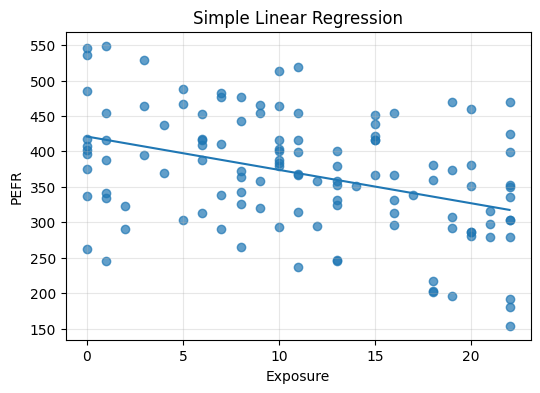

In [3]:
x_line = np.linspace(lung["Exposure"].min(), lung["Exposure"].max(), 100)
y_line = model.intercept_ + model.coef_[0] * x_line

plt.figure(figsize=(6, 4))
plt.scatter(lung["Exposure"], lung["PEFR"], alpha=0.7)
plt.plot(x_line, y_line)
plt.xlabel("Exposure")
plt.ylabel("PEFR")
plt.title("Simple Linear Regression")
plt.grid(alpha=0.3)
plt.show()

## Fitted Values and Residuals

Fitted values adalah nilai prediksi yang dihasilkan model. Residuals adalah error prediksi, yaitu selisih antara nilai aktual dan fitted value.

### Rumus Model dengan Error Term

$$
Y_i = b_0 + b_1X_i + e_i
$$

### Rumus Fitted Value

$$
\hat{Y}_i = \hat{b}_0 + \hat{b}_1X_i
$$

### Rumus Residual

$$
e_i = Y_i - \hat{Y}_i
$$

Keterangan:

- $\hat{Y}_i$ = fitted value atau predicted value
- $e_i$ = residual
- tanda topi atau hat menunjukkan bahwa nilai tersebut adalah estimasi dari data

In [4]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

lung_result = lung.copy()
lung_result["Fitted"] = fitted
lung_result["Residual"] = residuals

lung_result.head()

,Exposure,PEFR,Fitted,Residual
0,8,264.567566,383.306817,-118.739251
1,0,337.353060,420.980376,-83.627316
2,0,375.227035,420.980376,-45.753341
3,4,369.216430,402.143596,-32.927166
4,9,465.739198,378.597622,87.141575


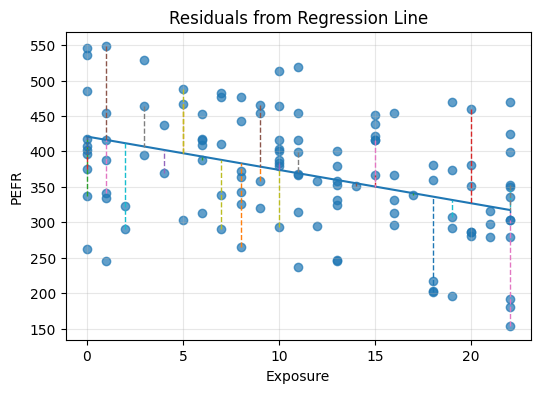

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(lung["Exposure"], lung["PEFR"], alpha=0.7)
plt.plot(x_line, y_line)

for xi, yi, yhat in zip(lung["Exposure"].iloc[:30], lung["PEFR"].iloc[:30], fitted[:30]):
    plt.plot([xi, xi], [yi, yhat], linestyle="--", linewidth=1)

plt.xlabel("Exposure")
plt.ylabel("PEFR")
plt.title("Residuals from Regression Line")
plt.grid(alpha=0.3)
plt.show()

## Least Squares

Linear regression biasanya di-fit dengan metode least squares. Metode ini memilih coefficient yang membuat jumlah kuadrat residual sekecil mungkin.

### Rumus Residual Sum of Squares

$$
RSS =
\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2
$$

atau:

$$
RSS =
\sum_{i=1}^{n}(Y_i-\hat{b}_0-\hat{b}_1X_i)^2
$$

Keterangan:

- $RSS$ = residual sum of squares
- $Y_i$ = nilai aktual
- $\hat{Y}_i$ = nilai prediksi
- $\hat{b}_0$ dan $\hat{b}_1$ = coefficient yang diestimasi

Least squares populer karena sederhana, cepat dihitung, dan tersedia di hampir semua software statistik.

In [6]:
rss = np.sum(residuals**2)
rmse_simple = np.sqrt(mean_squared_error(lung[outcome], fitted))

print("RSS:", round(rss, 2))
print("RMSE:", round(rmse_simple, 2))

RSS: 689594.86
RMSE: 75.81


## Prediction Versus Explanation

Regression dapat digunakan untuk dua tujuan berbeda:

| Tujuan | Fokus Utama |
|---|---|
| Explanation | Memahami hubungan antar variabel dan interpretasi coefficient. |
| Prediction | Menghasilkan fitted values atau prediksi untuk data baru. |

Dalam data science, regression lebih sering digunakan untuk prediction. Namun, regression equation sendiri tidak membuktikan causation. Kesimpulan kausal harus berasal dari desain penelitian, konteks domain, dan pemahaman proses yang lebih luas.

## Multiple Linear Regression

Multiple linear regression memperluas simple linear regression dengan memasukkan lebih dari satu predictor.

### Rumus Multiple Linear Regression

$$
Y =
b_0 + b_1X_1 + b_2X_2 + \cdots + b_pX_p + e
$$

Keterangan:

- $X_1, X_2, \ldots, X_p$ = predictor variables
- $b_1, b_2, \ldots, b_p$ = coefficients
- $p$ = jumlah predictors

Interpretasi coefficient dilakukan dengan asumsi predictor lain tetap konstan.

In [7]:
# Simulasi data housing seperti King County housing
n = 800

sqft_living = np.random.normal(2100, 700, n).clip(600, 6000)
sqft_lot = np.random.lognormal(9, 0.7, n)
bathrooms = np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4], size=n, p=[.08, .08, .25, .25, .18, .10, .06])
bedrooms = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[.04, .14, .36, .30, .12, .04])
bldg_grade = np.random.choice([5, 6, 7, 8, 9, 10, 11, 12], size=n, p=[.03, .10, .30, .28, .15, .08, .04, .02])
property_type = np.random.choice(["Multiplex", "Single Family", "Townhouse"], size=n, p=[.08, .72, .20])
year = np.random.randint(2006, 2016, size=n)

price = (
    -520000
    + 230 * sqft_living
    - 0.06 * sqft_lot
    - 19000 * bathrooms
    - 47000 * bedrooms
    + 106000 * bldg_grade
    + np.where(property_type == "Single Family", -85000, 0)
    + np.where(property_type == "Townhouse", -115000, 0)
    + np.random.normal(0, 180000, n)
)

house = pd.DataFrame({
    "AdjSalePrice": price,
    "SqFtTotLiving": sqft_living,
    "SqFtLot": sqft_lot,
    "Bathrooms": bathrooms,
    "Bedrooms": bedrooms,
    "BldgGrade": bldg_grade,
    "PropertyType": property_type,
    "Year": year
})

predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f"Intercept: {house_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(predictors, house_lm.coef_):
    print(f"  {name}: {coef:.3f}")

Intercept: -530938.980
Coefficients:
  SqFtTotLiving: 225.282
  SqFtLot: 0.386
  Bathrooms: -17203.365
  Bedrooms: -38642.827
  BldgGrade: 94529.232


## Assessing the Model

Dari perspektif data science, metrik penting untuk regression adalah ukuran kesalahan prediksi. Chapter menekankan RMSE sebagai metrik utama untuk membandingkan model.

### Rumus RMSE

$$
RMSE =
\sqrt{
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{n}
}
$$

### Rumus RSE

$$
RSE =
\sqrt{
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{n-p-1}
}
$$

Keterangan:

- $n$ = jumlah records
- $p$ = jumlah predictors
- RMSE menggunakan denominator $n$
- RSE menggunakan degrees of freedom $n-p-1$

## Rumus $R^2$ dan t-Statistic

$R^2$ menunjukkan proporsi variasi outcome yang dijelaskan oleh model.

$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$

t-statistic digunakan untuk melihat kontribusi relatif suatu predictor dalam model statistik.

$$
t_b =
\frac{b}{SE(b)}
$$

Dalam data science, t-statistic dapat membantu memilih predictor, tetapi fokus utama tetap pada predictive performance.

In [8]:
fitted = house_lm.predict(house[predictors])

rmse = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)

p = len(predictors)
n_records = len(house)
rse = np.sqrt(np.sum((house[outcome] - fitted)**2) / (n_records - p - 1))

print(f"RMSE: {rmse:.0f}")
print(f"RSE : {rse:.0f}")
print(f"R²  : {r2:.4f}")

RMSE: 182838
RSE : 183527
R²  : 0.5511


In [9]:
if STATSMODELS_AVAILABLE:
    X_sm = sm.add_constant(house[predictors])
    results = sm.OLS(house[outcome], X_sm).fit()
    print(results.summary())
else:
    print("statsmodels tidak tersedia di environment ini.")

statsmodels tidak tersedia di environment ini.


## Cross-Validation

Metrik seperti $R^2$, p-value, dan F-statistic biasanya dihitung pada data yang sama dengan data training. Dalam data science, performa model lebih baik dinilai menggunakan data yang tidak digunakan saat training.

Cross-validation memperluas gagasan holdout sample menjadi beberapa fold. Pada k-fold cross-validation, data dibagi menjadi $k$ bagian. Setiap bagian bergiliran menjadi holdout, sementara bagian lainnya digunakan untuk training.

In [10]:
X = house[predictors]
y = house[outcome]

cv = KFold(n_splits=5, shuffle=True, random_state=2024)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print("RMSE per fold:", np.round(-cv_scores, 0))
print("Average CV RMSE:", round(-cv_scores.mean(), 0))

RMSE per fold: [192528. 177231. 181055. 173405. 195747.]
Average CV RMSE: 183993.0


## Model Selection and Stepwise Regression

Menambah predictor hampir selalu menurunkan RMSE training dan menaikkan $R^2$ training. Karena itu, training metrics tidak selalu cocok untuk memilih model terbaik. Model yang terlalu kompleks dapat menangkap noise.

Chapter membahas beberapa pendekatan model selection:

| Metode | Penjelasan |
|---|---|
| Adjusted $R^2$ | Mengoreksi $R^2$ berdasarkan jumlah predictor. |
| AIC | Penalti model berdasarkan jumlah parameter dan RSS. |
| Stepwise regression | Menambah atau menghapus predictor secara bertahap. |
| Penalized regression | Memberi penalti pada coefficient, misalnya ridge dan lasso. |

## Rumus Adjusted $R^2$ dan AIC

Adjusted $R^2$:

$$
R^2_{adj}
=
1 -
(1-R^2)
\frac{n-1}{n-P-1}
$$

AIC untuk regression:

$$
AIC =
2P + n\log(RSS/n)
$$

Keterangan:

- $P$ = jumlah variables atau parameters
- $n$ = jumlah records
- $RSS$ = residual sum of squares

Tujuan AIC adalah mencari model dengan nilai AIC paling kecil.

In [11]:
def adjusted_r2(r2, n, p):
    return 1 - (1-r2) * (n-1) / (n-p-1)

def aic_score(y_true, y_pred, p):
    rss = np.sum((y_true - y_pred)**2)
    n = len(y_true)
    return 2*p + n*np.log(rss/n)

base_adj_r2 = adjusted_r2(r2, len(house), len(predictors))
base_aic = aic_score(house[outcome], fitted, len(predictors)+1)

print("Adjusted R²:", round(base_adj_r2, 4))
print("AIC:", round(base_aic, 2))

Adjusted R²: 0.5483
AIC: 19398.17


In [12]:
# Ilustrasi penalized regression
X_full = pd.get_dummies(
    house[["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade", "PropertyType"]],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, house[outcome], test_size=0.25, random_state=2024
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1000),
    "Lasso": Lasso(alpha=1000, max_iter=10000)
}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    print(f"{name} RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 0))

Linear Regression RMSE: 186304.0
Ridge RMSE: 198007.0
Lasso RMSE: 187181.0


## Weighted Regression

Weighted regression memberi bobot berbeda pada records. Bobot digunakan ketika beberapa observasi dianggap lebih reliabel, lebih presisi, atau merepresentasikan lebih banyak kasus.

Contoh pada chapter adalah housing data, di mana penjualan terbaru dianggap lebih relevan daripada penjualan lama. Bobot dapat diberikan melalui `sample_weight` pada `fit()` di scikit-learn.

In [13]:
house["Weight"] = house["Year"] - 2005

weighted_lm = LinearRegression()
weighted_lm.fit(house[predictors], house[outcome], sample_weight=house["Weight"])

coef_compare = pd.DataFrame({
    "predictor": predictors,
    "ordinary_regression": house_lm.coef_,
    "weighted_regression": weighted_lm.coef_
})

coef_compare

,predictor,ordinary_regression,weighted_regression
0,SqFtTotLiving,225.282255,230.814706
1,SqFtLot,0.385674,-0.126282
2,Bathrooms,-17203.365325,-10822.228585
3,Bedrooms,-38642.827137,-32889.290656
4,BldgGrade,94529.231873,95772.360431


## Prediction Using Regression

Dalam data science, tujuan utama regression sering kali adalah memprediksi outcome untuk data baru. Namun, regression model tidak boleh digunakan untuk extrapolation yang jauh di luar range data training.

Extrapolation dapat menghasilkan prediksi tidak masuk akal karena model tidak memiliki informasi pada area tersebut. Contoh pada chapter adalah memprediksi harga tanah kosong dengan model yang dilatih hanya pada rumah yang memiliki bangunan.

In [14]:
new_house_valid = pd.DataFrame({
    "SqFtTotLiving": [2500],
    "SqFtLot": [7000],
    "Bathrooms": [2.5],
    "Bedrooms": [4],
    "BldgGrade": [8]
})

new_house_invalid = pd.DataFrame({
    "SqFtTotLiving": [0],
    "SqFtLot": [5000],
    "Bathrooms": [0],
    "Bedrooms": [0],
    "BldgGrade": [0]
})

print("Prediction for valid-like house:", round(house_lm.predict(new_house_valid)[0], 0))
print("Prediction for extrapolated vacant lot:", round(house_lm.predict(new_house_invalid)[0], 0))

Prediction for valid-like house: 593621.0
Prediction for extrapolated vacant lot: -529011.0


## Confidence Intervals and Prediction Intervals

Confidence interval dan prediction interval sama-sama menggambarkan ketidakpastian, tetapi objeknya berbeda.

| Interval | Makna |
|---|---|
| Confidence interval | Ketidakpastian terhadap mean atau parameter, misalnya coefficient. |
| Prediction interval | Ketidakpastian terhadap satu prediksi individual. |

Prediction interval biasanya lebih lebar dibanding confidence interval karena mencakup uncertainty model dan error individual data point.

In [15]:
# Bootstrap sederhana untuk prediction interval
B = 300
new_x = new_house_valid[predictors]
base_residuals = house[outcome] - fitted

boot_preds = []

for _ in range(B):
    sample_idx = np.random.choice(house.index, size=len(house), replace=True)
    boot_sample = house.loc[sample_idx]

    boot_model = LinearRegression()
    boot_model.fit(boot_sample[predictors], boot_sample[outcome])

    pred_value = boot_model.predict(new_x)[0]
    pred_with_residual = pred_value + np.random.choice(base_residuals)
    boot_preds.append(pred_with_residual)

boot_preds = np.array(boot_preds)
pred_interval = np.percentile(boot_preds, [2.5, 97.5])

print("Bootstrap prediction interval:")
print(np.round(pred_interval, 0))

Bootstrap prediction interval:
[227142. 935259.]


## Factor Variables in Regression

Regression memerlukan input numeric. Karena itu, factor variables atau categorical variables perlu diubah menjadi dummy variables.

Jika suatu factor variable memiliki $P$ level dan model memiliki intercept, biasanya hanya $P-1$ dummy variables yang digunakan. Hal ini dilakukan untuk menghindari multicollinearity.

In [16]:
property_dummies_full = pd.get_dummies(house["PropertyType"])
property_dummies_reference = pd.get_dummies(house["PropertyType"], drop_first=True)

print("One-hot encoding:")
display(property_dummies_full.head())

print("Reference coding with drop_first=True:")
display(property_dummies_reference.head())

One-hot encoding:


,Multiplex,Single Family,Townhouse
0,False,True,False
1,False,True,False
2,False,True,False
3,False,False,True
4,True,False,False


Reference coding with drop_first=True:


,Single Family,Townhouse
0,True,False
1,True,False
2,True,False
3,False,True
4,False,False


In [17]:
factor_predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade", "PropertyType"]
X_factor = pd.get_dummies(house[factor_predictors], drop_first=True)

factor_model = LinearRegression()
factor_model.fit(X_factor, house[outcome])

print(f"Intercept: {factor_model.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(X_factor.columns, factor_model.coef_):
    print(f"  {name}: {coef:.3f}")

Intercept: -455963.978
Coefficients:
  SqFtTotLiving: 226.504
  SqFtLot: 0.102
  Bathrooms: -16816.181
  Bedrooms: -38476.303
  BldgGrade: 95690.924
  PropertyType_Single Family: -87121.710
  PropertyType_Townhouse: -114735.789


## Factor Variables with Many Levels and Ordered Factors

Factor variables dengan terlalu banyak level dapat menghasilkan banyak dummy variables. Contoh pada chapter adalah zip code. Jika terdapat 80 zip codes, maka reference coding membutuhkan 79 dummy variables. Dalam kasus seperti ini, level dapat dikonsolidasikan berdasarkan informasi lain, misalnya median residual.

Ordered factor variables berbeda karena level-nya memiliki urutan. Jika urutan bermakna, variable tersebut dapat diperlakukan sebagai numeric. Contohnya adalah `BldgGrade`, yang semakin besar nilainya menunjukkan kualitas bangunan yang lebih tinggi.

## Interpreting the Regression Equation

Interpretasi coefficient dalam multiple regression harus dilakukan hati-hati. Coefficient menunjukkan perubahan outcome untuk satu unit perubahan predictor, dengan asumsi predictor lain tetap konstan.

Namun, interpretasi dapat terganggu oleh:

| Masalah | Dampak |
|---|---|
| Correlated predictors | Coefficient dapat berubah tanda atau sulit ditafsirkan. |
| Multicollinearity | Model menjadi tidak stabil atau tidak dapat dihitung. |
| Confounding variables | Hubungan palsu muncul karena predictor penting dihilangkan. |
| Interactions | Efek satu predictor bergantung pada nilai predictor lain. |

## Correlated Predictors

Predictor dalam regression sering saling berkorelasi. Contoh pada chapter adalah bedrooms, house size, dan bathrooms. Rumah yang lebih besar cenderung memiliki lebih banyak kamar tidur, sehingga coefficient bedrooms dapat tampak negatif ketika size sudah dikontrol.

Hal ini tidak selalu berarti bedroom menurunkan harga secara langsung. Interpretasinya adalah: untuk dua rumah dengan ukuran sama, rumah dengan lebih banyak kamar tidur mungkin memiliki kamar lebih kecil dan bisa dinilai kurang menarik.

In [18]:
corr_cols = ["SqFtTotLiving", "Bathrooms", "Bedrooms", "BldgGrade"]
corr_matrix = house[corr_cols].corr()

corr_matrix

,SqFtTotLiving,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.000000,0.048906,-0.020650,-0.075614
Bathrooms,0.048906,1.000000,-0.038435,-0.006932
Bedrooms,-0.020650,-0.038435,1.000000,0.021137
BldgGrade,-0.075614,-0.006932,0.021137,1.000000


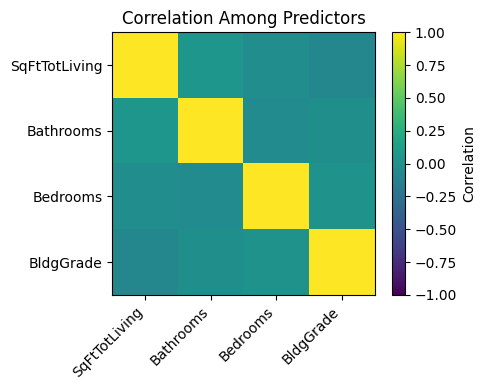

In [19]:
plt.figure(figsize=(5, 4))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Among Predictors")
plt.tight_layout()
plt.show()

## Multicollinearity

Multicollinearity adalah kondisi ketika satu predictor dapat diekspresikan sebagai kombinasi linear predictor lain. Perfect multicollinearity dapat membuat regression tidak memiliki solusi yang terdefinisi dengan baik.

Multicollinearity dapat terjadi jika:

- variable yang sama dimasukkan lebih dari sekali,
- seluruh $P$ dummy variables dimasukkan bersama intercept,
- dua variables hampir perfectly correlated.

Solusinya adalah menghapus atau menggabungkan variables yang redundant.

In [20]:
# Ilustrasi multicollinearity: duplicate predictor
X_multi = house[["SqFtTotLiving", "Bathrooms", "Bedrooms"]].copy()
X_multi["SqFtTotLiving_duplicate"] = X_multi["SqFtTotLiving"]

print("Matrix rank:", np.linalg.matrix_rank(X_multi))
print("Number of columns:", X_multi.shape[1])

Matrix rank: 3
Number of columns: 4


## Confounding Variables

Confounding variable adalah predictor penting yang dihilangkan dari model sehingga hubungan antar variable lain menjadi misleading. Dalam housing data, location adalah contoh confounder yang kuat karena harga rumah sangat dipengaruhi lokasi.

Jika location diabaikan, coefficient dari variable lain dapat menangkap efek lokasi secara tidak langsung. Salah satu strategi yang dibahas chapter adalah mengelompokkan zip code berdasarkan median residual dari model awal.

In [21]:
# Simulasi confounding location melalui ZipGroup
house["ZipGroup"] = pd.qcut(house["AdjSalePrice"], q=5, labels=False)

X_no_location = house[predictors]
X_with_location = pd.get_dummies(house[predictors + ["ZipGroup"]], columns=["ZipGroup"], drop_first=True)

model_no_location = LinearRegression().fit(X_no_location, house[outcome])
model_with_location = LinearRegression().fit(X_with_location, house[outcome])

pred_no_location = model_no_location.predict(X_no_location)
pred_with_location = model_with_location.predict(X_with_location)

print("RMSE without ZipGroup:", round(np.sqrt(mean_squared_error(house[outcome], pred_no_location)), 0))
print("RMSE with ZipGroup   :", round(np.sqrt(mean_squared_error(house[outcome], pred_with_location)), 0))

RMSE without ZipGroup: 182838.0
RMSE with ZipGroup   : 79049.0


## Interactions and Main Effects

Main effect adalah efek langsung suatu predictor terhadap outcome. Interaction terjadi ketika efek satu predictor bergantung pada nilai predictor lain.

Contoh bentuk interaction:

$$
Y = b_0 + b_1X_1 + b_2X_2 + b_3X_1X_2 + e
$$

Keterangan:

- $b_1X_1$ dan $b_2X_2$ = main effects
- $b_3X_1X_2$ = interaction effect

Interaction penting ketika hubungan antar predictor tidak additive secara sederhana.

In [22]:
house["SqFt_BldgGrade"] = house["SqFtTotLiving"] * house["BldgGrade"]

interaction_predictors = predictors + ["SqFt_BldgGrade"]

interaction_model = LinearRegression()
interaction_model.fit(house[interaction_predictors], house[outcome])

pred_interaction = interaction_model.predict(house[interaction_predictors])

print("RMSE base model       :", round(rmse, 0))
print("RMSE interaction model:", round(np.sqrt(mean_squared_error(house[outcome], pred_interaction)), 0))

RMSE base model       : 182838.0
RMSE interaction model: 182833.0


## Regression Diagnostics

Regression diagnostics menggunakan residuals dan fitted values untuk melihat apakah model memiliki masalah. Dalam data science, diagnostics lebih berguna untuk menemukan sinyal yang belum ditangkap model, bukan hanya untuk memvalidasi asumsi statistik formal.

Beberapa diagnostics yang dibahas chapter:

| Diagnostic | Tujuan |
|---|---|
| Standardized residuals | Mendeteksi outliers. |
| Leverage | Melihat record dengan nilai predictor ekstrem. |
| Cook's distance | Mendeteksi influential values. |
| Residual plot | Melihat heteroskedasticity atau nonlinearity. |
| Partial residual plot | Melihat hubungan nonlinear setelah mengontrol predictor lain. |

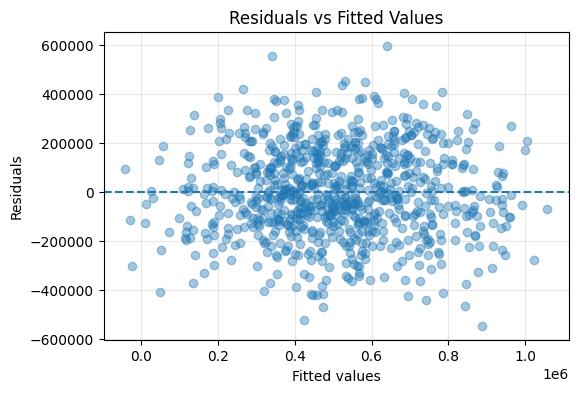

In [23]:
residuals_house = house[outcome] - fitted

plt.figure(figsize=(6, 4))
plt.scatter(fitted, residuals_house, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.grid(alpha=0.3)
plt.show()

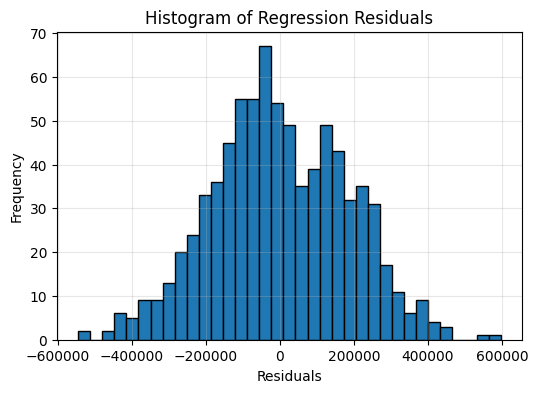

In [24]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_house, bins=35, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Regression Residuals")
plt.grid(alpha=0.3)
plt.show()

## Outliers and Influential Values

Outlier adalah record dengan residual besar. Outlier pada response value belum tentu sangat memengaruhi model jika predictor-nya tidak ekstrem.

Influential value adalah record yang sangat memengaruhi regression equation. Record seperti ini biasanya memiliki leverage tinggi dan residual besar. Cook's distance menggabungkan informasi residual dan leverage untuk mengidentifikasi influential values.

In [25]:
if STATSMODELS_AVAILABLE:
    X_sm = sm.add_constant(house[predictors])
    results = sm.OLS(house[outcome], X_sm).fit()
    influence = results.get_influence()

    standardized_residuals = influence.resid_studentized_internal
    cooks_distance = influence.cooks_distance[0]

    diag = pd.DataFrame({
        "standardized_residual": standardized_residuals,
        "cooks_distance": cooks_distance
    })

    display(diag.sort_values("cooks_distance", ascending=False).head())
else:
    print("statsmodels tidak tersedia di environment ini.")

statsmodels tidak tersedia di environment ini.


In [26]:
if STATSMODELS_AVAILABLE:
    plt.figure(figsize=(6, 4))
    plt.scatter(range(len(cooks_distance)), cooks_distance, alpha=0.5)
    plt.xlabel("Record index")
    plt.ylabel("Cook's distance")
    plt.title("Influential Values via Cook's Distance")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("statsmodels tidak tersedia di environment ini.")

statsmodels tidak tersedia di environment ini.


## Heteroskedasticity, Non-Normality, and Correlated Errors

Heteroskedasticity terjadi ketika variance residual berubah mengikuti fitted value atau predictor tertentu. Dalam data science, hal ini dapat mengindikasikan bahwa model belum menangkap pola penting.

Non-normal residuals dan correlated errors juga sering diperiksa oleh statisticians. Namun, untuk data science yang fokus pada prediction, pelanggaran asumsi distribusi tidak selalu menjadi masalah utama selama predictive performance baik dan model tidak kehilangan sinyal penting.

## Partial Residual Plots and Nonlinearity

Partial residual plot digunakan untuk melihat apakah hubungan antara predictor tertentu dan outcome bersifat linear setelah predictor lain dikontrol.

Jika pola residual menunjukkan lengkungan, hubungan mungkin nonlinear. Dalam kondisi ini, model linear biasa dapat diperluas dengan polynomial terms, splines, atau generalized additive models.

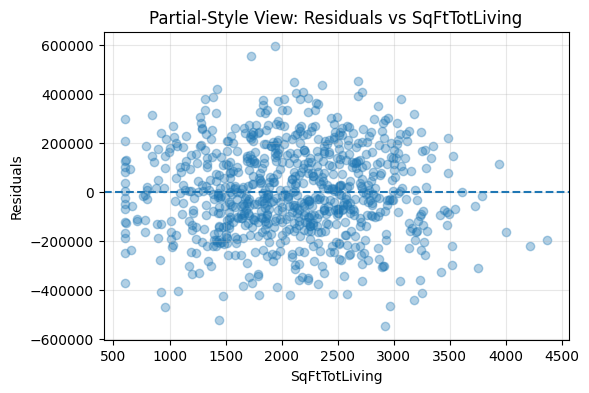

In [27]:
# Ilustrasi hubungan nonlinear antara SqFtTotLiving dan residual
plt.figure(figsize=(6, 4))
plt.scatter(house["SqFtTotLiving"], residuals_house, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("SqFtTotLiving")
plt.ylabel("Residuals")
plt.title("Partial-Style View: Residuals vs SqFtTotLiving")
plt.grid(alpha=0.3)
plt.show()

## Polynomial Regression

Polynomial regression menambahkan pangkat predictor untuk menangkap hubungan nonlinear.

### Rumus Polynomial Regression

$$
Y =
b_0 + b_1X + b_2X^2 + \cdots + b_dX^d + e
$$

Keterangan:

- $d$ = degree polynomial
- semakin tinggi degree, semakin fleksibel model
- degree terlalu tinggi dapat menghasilkan model yang terlalu bergelombang atau overfit

Chapter menekankan bahwa polynomial regression dapat membantu, tetapi degree tinggi sering membuat bentuk model sulit ditafsirkan.

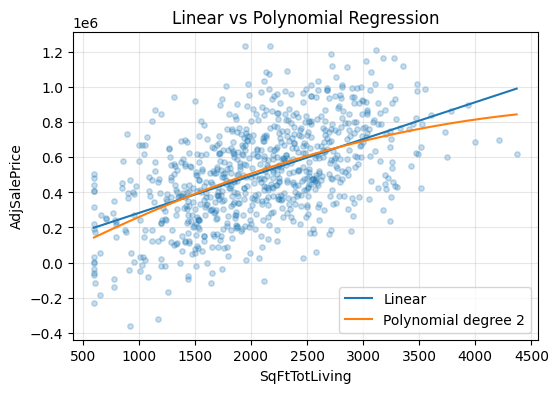

In [28]:
# Contoh polynomial regression pada satu predictor
X_poly = house[["SqFtTotLiving"]]
y_poly = house["AdjSalePrice"]

poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

linear_model = LinearRegression()

linear_model.fit(X_poly, y_poly)
poly_model.fit(X_poly, y_poly)

x_grid = np.linspace(X_poly.min().iloc[0], X_poly.max().iloc[0], 200).reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X_poly, y_poly, alpha=0.25, s=15)
plt.plot(x_grid, linear_model.predict(x_grid), label="Linear")
plt.plot(x_grid, poly_model.predict(x_grid), label="Polynomial degree 2")
plt.xlabel("SqFtTotLiving")
plt.ylabel("AdjSalePrice")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Splines

Splines memodelkan hubungan nonlinear dengan piecewise polynomials yang tersambung secara halus pada titik-titik tertentu yang disebut knots.

Konsep penting:

| Istilah | Penjelasan |
|---|---|
| Spline | Rangkaian polynomial yang disambung secara halus. |
| Knot | Titik pada predictor tempat potongan polynomial tersambung. |
| Degree | Derajat polynomial pada setiap segmen. |
| B-spline | Basis spline yang umum digunakan dalam software statistik. |

Coefficient spline biasanya tidak ditafsirkan satu per satu. Interpretasi lebih baik dilakukan melalui visualisasi fitted curve.

In [29]:
if STATSMODELS_AVAILABLE and PATSY_AVAILABLE:
    spline_df = house.sample(300, random_state=2024).copy()
    spline_basis = dmatrix(
        "bs(SqFtTotLiving, df=6, degree=3, include_intercept=False)",
        data=spline_df,
        return_type="dataframe"
    )

    spline_model = LinearRegression()
    spline_model.fit(spline_basis, spline_df["AdjSalePrice"])

    x_grid_df = pd.DataFrame({
        "SqFtTotLiving": np.linspace(spline_df["SqFtTotLiving"].min(), spline_df["SqFtTotLiving"].max(), 200)
    })
    spline_grid = dmatrix(
        "bs(SqFtTotLiving, df=6, degree=3, include_intercept=False)",
        data=x_grid_df,
        return_type="dataframe"
    )

    plt.figure(figsize=(6, 4))
    plt.scatter(spline_df["SqFtTotLiving"], spline_df["AdjSalePrice"], alpha=0.35, s=15)
    plt.plot(x_grid_df["SqFtTotLiving"], spline_model.predict(spline_grid), label="Spline fit")
    plt.xlabel("SqFtTotLiving")
    plt.ylabel("AdjSalePrice")
    plt.title("Spline Regression")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("statsmodels atau patsy tidak tersedia di environment ini.")

statsmodels atau patsy tidak tersedia di environment ini.


## Generalized Additive Models

Generalized Additive Models atau GAM digunakan ketika hubungan antara response dan predictor diduga nonlinear, tetapi bentuk knot spline tidak ingin ditentukan manual. GAM dapat memodelkan efek smooth dari predictor.

Secara konsep, GAM dapat ditulis sebagai:

$$
Y =
b_0 + f_1(X_1) + f_2(X_2) + \cdots + f_p(X_p) + e
$$

Keterangan:

- $f_j(X_j)$ = fungsi smooth untuk predictor ke-$j$
- GAM tetap additive, tetapi setiap efek predictor tidak harus linear

Chapter menjelaskan GAM sebagai pendekatan fleksibel untuk otomatis memilih bentuk smooth relationship.

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Regression | Model hubungan antara predictor dan response. |
| Simple linear regression | Regression dengan satu predictor. |
| Multiple linear regression | Regression dengan banyak predictor. |
| Intercept | Prediksi saat predictor bernilai nol. |
| Coefficient | Perubahan prediksi untuk satu unit perubahan predictor. |
| Fitted value | Nilai prediksi dari model. |
| Residual | Selisih nilai aktual dan prediksi. |
| Least squares | Metode fitting yang meminimalkan RSS. |
| RMSE | Metrik utama error prediksi regresi. |
| RSE | RMSE yang disesuaikan degrees of freedom. |
| $R^2$ | Proporsi variance outcome yang dijelaskan model. |
| Cross-validation | Validasi out-of-sample dengan beberapa holdout folds. |
| Stepwise regression | Pemilihan predictor secara bertahap. |
| Weighted regression | Regression dengan bobot berbeda untuk setiap record. |
| Extrapolation | Prediksi di luar range data training yang berisiko. |
| Prediction interval | Interval ketidakpastian untuk prediksi individual. |
| Dummy variables | Representasi numeric untuk categorical variables. |
| Multicollinearity | Redundansi linear antar predictors. |
| Confounding | Predictor penting yang hilang dan mengganggu interpretasi. |
| Interaction | Efek satu predictor bergantung pada predictor lain. |
| Regression diagnostics | Pemeriksaan residual dan influence untuk mengevaluasi model. |
| Polynomial regression | Regression dengan pangkat predictor. |
| Splines | Piecewise polynomial yang tersambung halus pada knots. |
| GAM | Model additive dengan fungsi smooth pada predictors. |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa regression merupakan salah satu metode paling penting dalam statistik dan data science. Simple linear regression memodelkan hubungan antara satu predictor dan satu response, sedangkan multiple linear regression memperluasnya ke banyak predictors.

Model regression menghasilkan fitted values dan residuals. Least squares digunakan untuk memilih coefficient yang meminimalkan residual sum of squares. Dari perspektif data science, regression terutama digunakan untuk prediction, sedangkan dari perspektif statistik klasik, regression juga digunakan untuk explanation dan interpretasi hubungan antar variabel.

Evaluasi model dapat dilakukan melalui RMSE, RSE, $R^2$, adjusted $R^2$, t-statistic, dan cross-validation. Namun, metrik in-sample tidak cukup untuk menilai kemampuan prediksi model, sehingga out-of-sample validation seperti cross-validation menjadi penting.

Chapter ini juga menekankan bahwa interpretasi coefficient harus hati-hati. Correlated predictors, multicollinearity, confounding variables, dan interactions dapat membuat coefficient sulit ditafsirkan secara langsung. Factor variables perlu diubah menjadi dummy variables, dan factor dengan banyak level dapat perlu dikonsolidasikan.

Regression diagnostics digunakan untuk mengevaluasi residuals, outliers, influential values, heteroskedasticity, dan nonlinearity. Jika hubungan linear tidak cukup, model dapat diperluas dengan polynomial regression, splines, atau generalized additive models. Secara keseluruhan, chapter ini menghubungkan regression sebagai alat interpretasi statistik dan sebagai fondasi prediction dalam data science.